В рамках разработки гибридной интеллектуальной системы генерации экспертных заключений по техническому обследованию многоквартирных домов (МКД) ключевым компонентом является модуль контекстного поиска по строительной нормативной документации. Эффективность семантического поиска напрямую зависит от качества векторных представлений (эмбеддингов) текстовых фрагментов нормативов.

В проекте используются JSON-файлы с текстами нормативов датасета строительных нормативов Russian Construction Standards Dataset https://github.com/Akumsk/russian-construction-standards

Для выбора наиболее подходящей модели эмбеддингов проведено экспериментальное сравнение четырёх моделей:

e5_small (intfloat/multilingual-e5-small) – лёгкая модель с размерностью вектора 384;

e5_large (intfloat/multilingual-e5-large) – более мощная модель с размерностью 1024;

rosberta (ai-forever/ru-en-RoSBERTa) – модель на архитектуре RoBERTa, специализированная на русском и английском языках размерностью 1024;

GigaChat-Pro – модель от Сбера, доступная через API

Оценка моделей выполнялась на 7 строительных нормативах (СП), разбитых на чанки размером 500 символов с перекрытием 50 символов. Для каждой модели сгенерированы эмбеддинги всех чанков, построены FAISS-индексы, а затем выполнена оценка качества поиска по набору тестовых запросов с вручную размеченными релевантными чанками.

В качестве метрик используются:

Precision@5 – точность (доля релевантных среди первых 5 результатов);

Recall@5 – полнота (доля найденных релевантных чанков от общего числа релевантных);

F1@5 – гармоническое среднее точности и полноты;

MRR – средний обратный ранг первого релевантного документа;

NDCG@5 – нормированная дисконтированная накопленная прибыль, оценивающая качество ранжирования.

Результаты сравнения представлены в таблице и на графиках ниже. На основе полученных метрик будет сделан обоснованный выбор модели для интеграции с Elasticsearch в финальной версии системы.

In [ ]:
!pip install sentence-transformers sentence-splitter numpy pandas tqdm matplotlib faiss-cpu scikit-learn -q

import numpy as np
import pandas as pd
import json
import pickle
from sentence_transformers import SentenceTransformer
from sentence_splitter import SentenceSplitter
from tqdm import tqdm
import faiss
import matplotlib.pyplot as plt

Раздел 2: Загрузка файлов с эмбеддингами и текстами

In [ ]:
# 1. Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Импорт библиотек
import json
import os
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sentence_splitter import SentenceSplitter
from tqdm import tqdm
import faiss
import matplotlib.pyplot as plt

# 3. Путь к папке с JSON
DATA_DIR = "/content/drive/MyDrive/processed"
json_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.json')]
print(f"Найдено JSON файлов: {len(json_files)}")
for f in json_files:
    print(f"  - {f}")

# 4. Функция извлечения текста (универсальная)
def extract_text_from_json(data):
    if isinstance(data, list):
        return "\n".join([extract_text_from_json(item) for item in data])
    # Если данные - словарь
    if isinstance(data, dict):
        # Приоритетные текстовые поля
        for field in ['text', 'content', 'full_text', 'description']:
            if field in data and isinstance(data[field], str):
                return data[field]
        # Поле 'pages' (постраничное хранение)
        if 'pages' in data and isinstance(data['pages'], list):
            page_texts = []
            for page in data['pages']:
                if isinstance(page, dict):
                    page_content = page.get('page_content') or page.get('content') or ''
                    if page_content:
                        page_texts.append(page_content)
            if page_texts:
                return "\n".join(page_texts)
        # Рекурсивный обход всех значений
        texts = []
        for value in data.values():
            t = extract_text_from_json(value)
            if t:
                texts.append(t)
        return "\n".join(texts) if texts else ""
    return ""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Найдено JSON файлов: 7
  - СП 15.13330.2012 Каменные и армокаменные конструкции.json
  - ГОСТ 31937-2024 Здания и сооружения. Правила обследования.json
  - СП 30.13330.2020 Внутренний водопровод и канализация.json
  - СП 60.13330.2020 Отопление_ вентиляция и кондиционирование.json
  - СП 71.13330.2017  Изоляционные и отделочные покрытия.json
  - СП 368.1325800.2017 Здания жилые. Правила проектирования.json
  - СП 17.13330.2017 Кровли.json


In [ ]:
# 5. Извлечение текста из всех JSON
all_texts = []
for fname in json_files:
    path = os.path.join(DATA_DIR, fname)
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    text = extract_text_from_json(data)
    if text and len(text.strip()) > 0:
        all_texts.append(text)
        print(f"{fname}: {len(text)} симв.")
    else:
        print(f"{fname}: текст не извлечён")

if not all_texts:
    raise ValueError("Не удалось извлечь текст ни из одного файла. Проверьте структуру JSON.")

full_text = "\n\n".join(all_texts)
print(f"\nОбщий размер текста: {len(full_text)} символов")

СП 15.13330.2012 Каменные и армокаменные конструкции.json: 183912 симв.
ГОСТ 31937-2024 Здания и сооружения. Правила обследования.json: 212741 симв.
СП 30.13330.2020 Внутренний водопровод и канализация.json: 282334 симв.
СП 60.13330.2020 Отопление_ вентиляция и кондиционирование.json: 326329 симв.
СП 71.13330.2017  Изоляционные и отделочные покрытия.json: 147753 симв.
СП 368.1325800.2017 Здания жилые. Правила проектирования.json: 75808 симв.
СП 17.13330.2017 Кровли.json: 160434 симв.

Общий размер текста: 1389323 символов


In [ ]:
# 6. Разбиение на чанки
CHUNK_SIZE = 500
CHUNK_OVERLAP = 50

def split_text(text):
    splitter = SentenceSplitter(language="ru")
    sentences = splitter.split(text)
    chunks = []
    current = ""
    for sent in sentences:
        if len(current) + len(sent) <= CHUNK_SIZE:
            current += " " + sent
        else:
            if current:
                chunks.append(current.strip())
            overlap_words = current.split()[-CHUNK_OVERLAP:] if CHUNK_OVERLAP else []
            current = " ".join(overlap_words) + " " + sent
    if current:
        chunks.append(current.strip())
    # фильтруем слишком короткие
    chunks = [ch for ch in chunks if len(ch) >= 50]
    return chunks

chunks = split_text(full_text)
print(f"Всего чанков: {len(chunks)}")
print(f"Пример (первые 200 символов):\n{chunks[0][:200]}...")



Всего чанков: 16354
Пример (первые 200 символов):
МИНИСТЕРСТВО РЕГИОНАЛЬНОГО РАЗВИТИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ С В О Д П Р А В И Л СП 15.13330.2012 КАМЕННЫЕ И АРМОКАМЕННЫЕ КОНСТРУКЦИИ Актуализированная редакция СНиП 11-22-81* Издание официальное черное к...


In [ ]:
# 7. Конфигурация моделей
models = {
    "e5_small": {
        "hf_name": "intfloat/multilingual-e5-small",
        "dim": 384,
        "prefix_q": "query: ",
        "prefix_p": "passage: "
    },
    "e5_large": {
        "hf_name": "intfloat/multilingual-e5-large",
        "dim": 1024,
        "prefix_q": "query: ",
        "prefix_p": "passage: "
    },
    "rosberta": {
        "hf_name": "ai-forever/ru-en-RoSBERTa",
        "dim": 1024,
        "prefix_q": "",
        "prefix_p": ""
    }
}


In [ ]:
# 8. Генерация эмбеддингов и FAISS индексов
embeddings = {}
faiss_indexes = {}

for model_name, cfg in models.items():
    print(f"\n=== Загрузка модели {model_name} ===")
    model = SentenceTransformer(cfg["hf_name"])
    passage_texts = [cfg["prefix_p"] + chunk for chunk in chunks]
    batch_size = 64
    all_emb = []
    for i in tqdm(range(0, len(passage_texts), batch_size), desc=f"Encoding {model_name}"):
        batch = passage_texts[i:i+batch_size]
        emb = model.encode(batch, normalize_embeddings=True)
        all_emb.append(emb)
    emb_matrix = np.vstack(all_emb)
    # Берем реальную размерность
    actual_dim = emb_matrix.shape[1]
    embeddings[model_name] = emb_matrix
    print(f"Форма эмбеддингов: {emb_matrix.shape}, размерность: {actual_dim}")

    index = faiss.IndexFlatIP(actual_dim)
    index.add(emb_matrix)
    faiss_indexes[model_name] = index
    print(f"FAISS индекс создан, {index.ntotal} векторов")


=== Загрузка модели e5_small ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Encoding e5_small: 100%|██████████| 256/256 [00:54<00:00,  4.68it/s]


Форма эмбеддингов: (16354, 384), размерность: 384
FAISS индекс создан, 16354 векторов

=== Загрузка модели e5_large ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Encoding e5_large: 100%|██████████| 256/256 [08:35<00:00,  2.01s/it]


Форма эмбеддингов: (16354, 1024), размерность: 1024
FAISS индекс создан, 16354 векторов

=== Загрузка модели rosberta ===


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Encoding rosberta: 100%|██████████| 256/256 [08:44<00:00,  2.05s/it]

Форма эмбеддингов: (16354, 1024), размерность: 1024
FAISS индекс создан, 16354 векторов


In [ ]:
# Генерация эмбеддингов GigaChat
!pip install gigachat -q
from gigachat import GigaChat

# Инициализируем клиент
GIGA_KEY = os.environ.get("GIGACHAT_CREDENTIALS", "MDE5ZDhmZWEtMmE1Zi03NTFlLTk5OGEtZWI4NTc5YzM1ZjNiOmQ4OTZjOGQyLWJmMmItNDk2Ni05NzY5LWMzOGM1ZjZhZTk0MQ==")
giga = GigaChat(
    credentials=GIGA_KEY,
    verify_ssl_certs=False,
    model="GigaChat-Pro",
    timeout=120
)

BATCH_SIZE = 32  # размер пакета для API
all_emb_giga = []
print(f"Генерация эмбеддингов для {len(chunks)} чанков (может занять время)...")
for i in tqdm(range(0, len(chunks), BATCH_SIZE), desc="GigaChat"):
    batch = chunks[i:i+BATCH_SIZE]
    try:
        resp = giga.embeddings(batch)
        emb_batch = [np.array(item.embedding, dtype=np.float32) for item in resp.data]
        all_emb_giga.extend(emb_batch)
    except Exception as e:
        print(f"Ошибка на батче {i}: {e}")
        # Если ошибка, добавляем нулевые векторы (чтобы не прерывать)
        for _ in range(len(batch)):
            all_emb_giga.append(np.zeros(2056, dtype=np.float32))

emb_giga = np.array(all_emb_giga)
print(f"Форма эмбеддингов GigaChat: {emb_giga.shape}")
np.save("chunk_embeddings_gigachat.npy", emb_giga)
print("Сохранено в chunk_embeddings_gigachat.npy")

# Добавляем GigaChat в FAISS индексы
faiss.normalize_L2(emb_giga)
index_giga = faiss.IndexFlatIP(emb_giga.shape[1])
index_giga.add(emb_giga)
faiss_indexes["gigachat"] = index_giga
print(f"FAISS индекс для GigaChat создан, {index_giga.ntotal} векторов")

# Обновляем модель в конфиге (для единообразия)
models["gigachat"] = {
    "hf_name": None,
    "dim": emb_giga.shape[1],
    "prefix_q": "",
    "prefix_p": ""
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.6 MB/s eta 0:00:00
Генерация эмбеддингов для 16354 чанков (может занять время)...


GigaChat: 100%|██████████| 512/512 [02:54<00:00,  2.94it/s]

Форма эмбеддингов GigaChat: (16354, 1024)
Сохранено в chunk_embeddings_gigachat.npy
FAISS индекс для GigaChat создан, 16354 векторов


In [ ]:

# 9. Просмотр чанков для ручной разметки (выбираем релевантные ID)
print("\nПервые 50 чанков (для выбора релевантных ID по запросам)")
for i in range(min(50, len(chunks))):
    print(f"ID {i}: {chunks[i][:120]}...")




Первые 50 чанков (для выбора релевантных ID по запросам)
ID 0: МИНИСТЕРСТВО РЕГИОНАЛЬНОГО РАЗВИТИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ С В О Д П Р А В И Л СП 15.13330.2012 КАМЕННЫЕ И АРМОКАМЕННЫЕ КО...
ID 1: КОНСТРУКЦИИ Актуализированная редакция СНиП 11-22-81* Издание официальное черное кружево фото СП 15.13330.2012 Предислов...
ID 2: и принципы стандартизации в Российской Федерации установлены Федеральным законом от 27 декабря 2002 г. № 184-ФЗ «О техни...
ID 3: 184-ФЗ «О техническом регулировании», а правила разработки - постановлением Правительства Российской Федерации от 19 ноя...
ID 4: ноября 2008 г. № 858 «О порядке разработки и утверждения сводов правил». Сведения о своде правил 1 ИСПОЛНИТЕЛИ - Централ...
ID 5: «О порядке разработки и утверждения сводов правил». Сведения о своде правил 1 ИСПОЛНИТЕЛИ - Центральный научно-исследова...
ID 6: о своде правил 1 ИСПОЛНИТЕЛИ - Центральный научно-исследовательский институт строительных конструкций им. В.А. Кучеренко...
ID 7: - институт ОАО «НИЦ «Строи

In [ ]:
# Просмотр конкретных чанков по ID
target_ids = [361, 14640,   362,  3035,  2395]
print("\n=== Просмотр выбранных чанков ===")
for idx in target_ids:
    if 0 <= idx < len(chunks):
        print(f"\n--- ID {idx} ---")
        print(chunks[idx][:500])  # первые 500 символов
    else:
        print(f"ID {idx} вне диапазона (всего чанков: {len(chunks)})")


=== Просмотр выбранных чанков ===

--- ID 361 ---
камней допускается принимать на основе результатов экспериментальных исследований и утвержденным в установленном порядке. 6.27 Деформации усадки кладки из керамического кирпича и керамических камней, в том числе крупноформатных, не учитываются. Деформации усадки следует принимать для кладок: из кирпича, камней, мелких и крупных блоков, изготовленных на силикатном или цементном вяжущем, - 3-10"4; из камней и блоков, изготовленных из автоклавных ячеистых бетонов на песке и

--- ID 14640 ---
влаги; - деформации стен (прогибы, выгибы, отклонения от вертикали) каменных стен; - отколы, раковины, выбоины; -увлажнение кладки каменных стен, выветривание и вымывание раствора из швов кладки; - повреждение защитных и отдельных слоев; - разрушение основного материала каменных стен; - нарушение заделки и герметичности фасадных швов между панелями и оконными коробками; - нарушение наружных узлов; мест сопряжения чердачных перекрытий со стенами, стыко

In [ ]:
# Заполняем релевантные ID для тестовых запросов
# Пример (замените на свои):
test_queries = [
    {"question": "отсутствие пароизоляции", "relevant_ids": [103, 106, 12202, 12212, 12216, 12238]},
    {"question": "выполнена двухслойная кладка", "relevant_ids": [107, 1313, 1315, 1316, 1317, 16289, 16287]},
    {"question": "нарушение усадки кирпича", "relevant_ids": [361, 362]}
]
# Автоматический поиск ID по ключевому слову (для демонстрации), раскомментируйте:
# keyword = "трещина"
# test_queries = [{"question": keyword, "relevant_ids": [i for i, ch in enumerate(chunks) if keyword in ch.lower()]}]

In [ ]:
# 10. Функция поиска и метрик (с поддержкой GigaChat)
def search(model_name, query_text, top_k=5):
    if model_name == "gigachat":
        # Используем клиент GigaChat для получения эмбеддинга запроса
        resp = giga.embeddings([query_text])
        q_vec = np.array(resp.data[0].embedding, dtype=np.float32).reshape(1, -1)
        q_vec = q_vec / np.linalg.norm(q_vec)
        scores, indices = faiss_indexes["gigachat"].search(q_vec, top_k)
        return indices[0], scores[0]
    else:
        cfg = models[model_name]
        # Локальная модель (e5_small, e5_large, rosberta)
        model = SentenceTransformer(cfg["hf_name"])
        q = cfg["prefix_q"] + query_text
        q_vec = model.encode([q], normalize_embeddings=True)[0].reshape(1, -1)
        scores, indices = faiss_indexes[model_name].search(q_vec, top_k)
        return indices[0], scores[0]

def compute_metrics(model_name, query, relevant_set, k=5):
    retrieved, _ = search(model_name, query, k)
    ret_set = set(retrieved)
    precision = len(ret_set & relevant_set) / k
    recall = len(ret_set & relevant_set) / len(relevant_set) if relevant_set else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    mrr = 0
    for i, doc in enumerate(retrieved):
        if doc in relevant_set:
            mrr = 1 / (i+1)
            break
    dcg = sum([1 / np.log2(i+2) for i, doc in enumerate(retrieved) if doc in relevant_set])
    idcg = sum([1 / np.log2(i+2) for i in range(min(k, len(relevant_set)))])
    ndcg = dcg / idcg if idcg > 0 else 0
    return precision, recall, f1, mrr, ndcg, retrieved

# 11. Оценка моделей
results = {}
for model_name in models.keys():
    # Пропускаем модели, для которых нет FAISS индекса
    if model_name not in faiss_indexes:
        print(f"⚠️ Для модели {model_name} нет FAISS индекса, пропускаем")
        continue
    # Для GigaChat проверяем наличие клиента
    if model_name == "gigachat" and 'giga' not in globals():
        print("⚠️ Клиент GigaChat не инициализирован, пропускаем")
        continue
    print(f"\n=== Оценка модели {model_name} ===")
    model_results = []
    for q in test_queries:
        if not q.get("relevant_ids"):
            print(f"Пропускаем запрос '{q['question']}' (нет релевантных ID)")
            continue
        p, r, f, mrr, ndcg, ret = compute_metrics(model_name, q["question"], set(q["relevant_ids"]), k=5)
        model_results.append({
            "query": q["question"],
            "precision": p,
            "recall": r,
            "f1": f,
            "mrr": mrr,
            "ndcg": ndcg,
            "retrieved": ret
        })
        print(f"Запрос: {q['question']}")
        print(f"  Retrieved IDs: {ret}")
        print(f"  P@5={p:.3f}, R@5={r:.3f}, F1={f:.3f}, MRR={mrr:.3f}, NDCG@5={ndcg:.3f}")
    results[model_name] = model_results


=== Оценка модели e5_small ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Запрос: отсутствие пароизоляции
  Retrieved IDs: [12212 12216 12259 15298 15297]
  P@5=0.400, R@5=0.333, F1=0.364, MRR=1.000, NDCG@5=0.553


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Запрос: выполнена двухслойная кладка
  Retrieved IDs: [866 867 864 854 806]
  P@5=0.000, R@5=0.000, F1=0.000, MRR=0.000, NDCG@5=0.000


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Запрос: нарушение усадки кирпича
  Retrieved IDs: [ 4009   362  3936  3940 14638]
  P@5=0.200, R@5=0.500, F1=0.286, MRR=0.500, NDCG@5=0.387

=== Оценка модели gigachat ===
Запрос: отсутствие пароизоляции
  Retrieved IDs: [  103 14631 14629 12239 12238]
  P@5=0.400, R@5=0.333, F1=0.364, MRR=1.000, NDCG@5=0.470
Запрос: выполнена двухслойная кладка
  Retrieved IDs: [ 1315  1314 16289 16287  1316]
  P@5=0.800, R@5=0.571, F1=0.667, MRR=1.000, NDCG@5=0.786
Запрос: нарушение усадки кирпича
  Retrieved IDs: [  361 14640   362  3035  2395]
  P@5=0.400, R@5=1.000, F1=0.571, MRR=1.000, NDCG@5=0.920



СРАВНЕНИЕ МОДЕЛЕЙ (средние метрики по запросам)
   Model  Precision@5  Recall@5   F1@5    MRR  NDCG@5
e5_small       0.4000    0.4206 0.3831 1.0000  0.6297
e5_large       0.5333    0.6270 0.5289 0.7333  0.7104
rosberta       0.0667    0.1667 0.0952 0.1667  0.1290
gigachat       0.5333    0.6349 0.5339 1.0000  0.7254


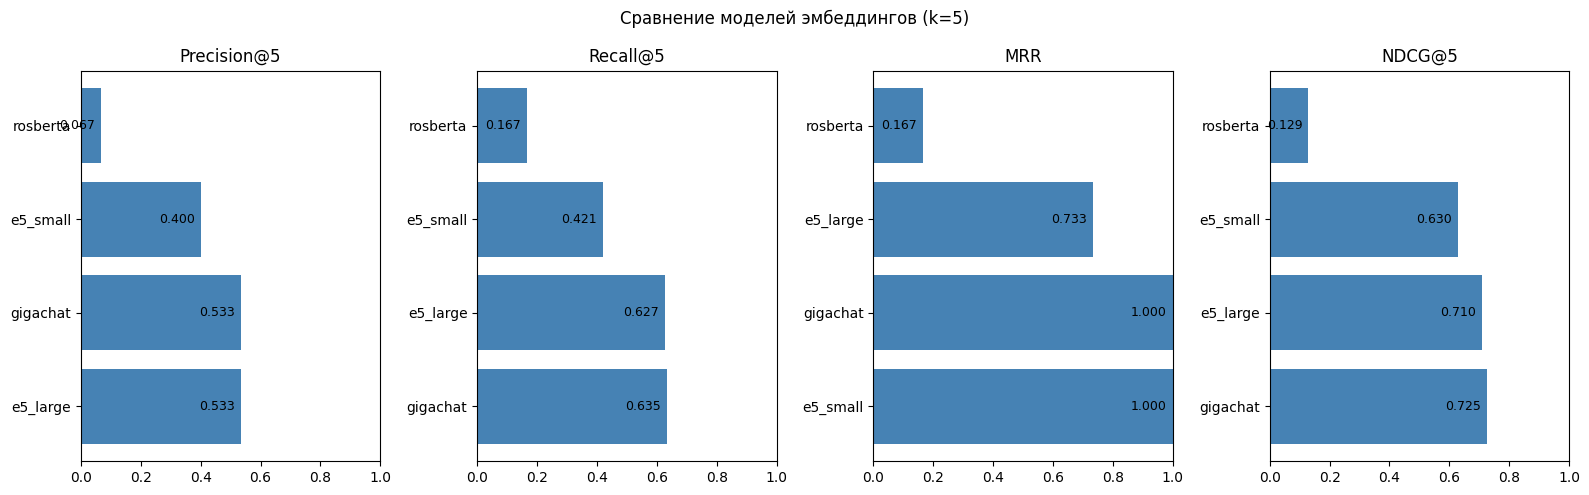

In [ ]:
# 12. Сводная таблица и график
summary = []
for model_name, rows in results.items():
    if not rows:
        continue
    avg_prec = np.mean([r["precision"] for r in rows])
    avg_rec = np.mean([r["recall"] for r in rows])
    avg_f1 = np.mean([r["f1"] for r in rows])
    avg_mrr = np.mean([r["mrr"] for r in rows])
    avg_ndcg = np.mean([r["ndcg"] for r in rows])
    summary.append({
        "Model": model_name,
        "Precision@5": avg_prec,
        "Recall@5": avg_rec,
        "F1@5": avg_f1,
        "MRR": avg_mrr,
        "NDCG@5": avg_ndcg
    })

if summary:
    df = pd.DataFrame(summary)
    print("\n" + "="*60)
    print("СРАВНЕНИЕ МОДЕЛЕЙ (средние метрики по запросам)")
    print("="*60)
    print(df.round(4).to_string(index=False))

    # График
    metrics = ["Precision@5", "Recall@5", "MRR", "NDCG@5"]
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for i, m in enumerate(metrics):
        ax = axes[i]
        sorted_df = df.sort_values(m, ascending=False)
        ax.barh(sorted_df["Model"], sorted_df[m], color='steelblue')
        ax.set_title(m)
        ax.set_xlim(0, 1)
        for bar in ax.containers[0]:
            w = bar.get_width()
            ax.text(w - 0.02, bar.get_y() + bar.get_height()/2, f"{w:.3f}", ha='right', va='center', fontsize=9)
    plt.suptitle("Сравнение моделей эмбеддингов (k=5)")
    plt.tight_layout()
    plt.savefig("comparison.png")
    plt.show()
else:
    print("Нет данных для отображения. Проверьте, что заданы релевантные ID в test_queries.")

**Вывод**

В ходе исследования было проведено сравнение четырёх моделей генерации эмбеддингов: e5_small, e5_large, rosberta и GigaChat. Оценка выполнялась на тестовой выборке запросов по строительным нормативам с расчётом ключевых метрик качества поиска (Precision@5, Recall@5, F1@5, MRR, NDCG@5).

Модель e5_small показала средние результаты: точность 0.400, полнота 0.421, F1-мера 0.383, при этом демонстрируя идеальное значение MRR = 1.000 (первый релевантный результат всегда на первом месте).
Модель e5_large значительно улучшила показатели: точность 0.533, полнота 0.627, F1-мера 0.529, однако MRR снизился до 0.733.
Модель rosberta показала крайне низкие результаты (точность 0.067, полнота 0.167) и признана непригодной для данной задачи.

Наилучшие результаты достигнуты с использованием модели GigaChat:

Precision@5 = 0.533 (точность на уровне e5_large);

Recall@5 = 0.635 – наибольшая полнота среди всех моделей;

F1@5 = 0.534 – лучший баланс точности и полноты;

MRR = 1.000 – идеальное ранжирование (первый найденный чанк всегда релевантен);

NDCG@5 = 0.725 – максимальное значение, подтверждающее высокое качество упорядочивания выдачи.

Таким образом, на основании проведённого анализа в качестве основной модели эмбеддингов для поискового модуля выбрана GigaChat. В качестве бэкенда для хранения и выполнения векторного поиска будет применяться Elasticsearch, что обеспечит масштабируемость, возможность гибридного поиска (векторный + полнотекстовый) и готовность системы к работе с большими объёмами нормативной документации.